In [1]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
base_dir = 'dataset'
categories = ['judiOnline', 'whitelist']  # Kategori folder
output_dir = 'split_dataset'  # Folder hasil split

# Split ratios
train_ratio = 0.8  # 80% training
val_ratio = 0.2    # 20% validation

# Create train and val directories
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')

for split_dir in [train_dir, val_dir]:
    for category in categories:
        os.makedirs(os.path.join(split_dir, category), exist_ok=True)

# Function to split dataset
def split_dataset(base_dir, categories, train_dir, val_dir, train_ratio):
    for category in categories:
        category_path = os.path.join(base_dir, category)
        images = os.listdir(category_path)
        
        # Split images
        train_images, val_images = train_test_split(images, test_size=1-train_ratio, random_state=42)
        
        # Copy images to respective folders
        for image in train_images:
            shutil.copy(os.path.join(category_path, image), os.path.join(train_dir, category, image))
        for image in val_images:
            shutil.copy(os.path.join(category_path, image), os.path.join(val_dir, category, image))
        print(f"Category: {category} - Train: {len(train_images)}, Validation: {len(val_images)}")

# Split dataset
split_dataset(base_dir, categories, train_dir, val_dir, train_ratio)
print("Dataset splitting completed.")


Category: judiOnline - Train: 125, Validation: 32
Category: whitelist - Train: 125, Validation: 32
Dataset splitting completed.


Augmentasi selesai. Gambar hasil disimpan di folder 'augmented_judiOnline'.


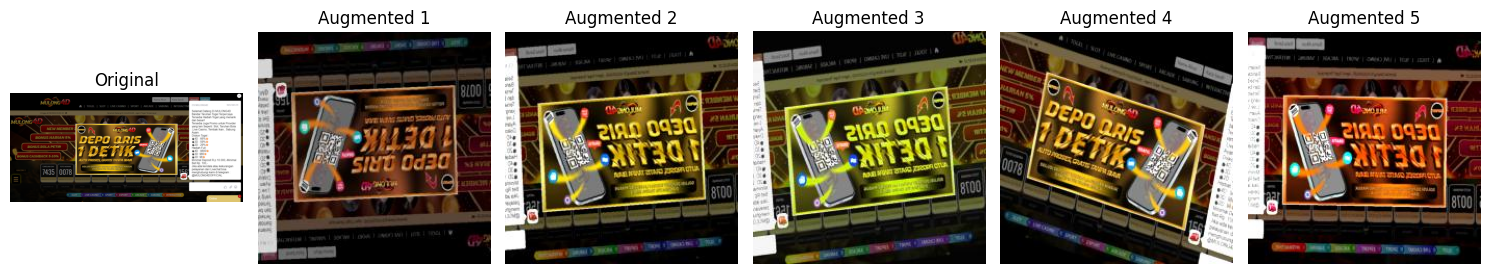

In [2]:
import os
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Direktori input dan output
input_dir = "dataset/judiOnline/"  # Folder yang berisi gambar asli
output_dir = "augmented_judiOnline"  # Folder untuk menyimpan gambar yang diaugmentasi

# Pastikan folder output ada
os.makedirs(output_dir, exist_ok=True)

# Transformasi augmentasi
augmentations = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # Horizontal flipping
    transforms.RandomVerticalFlip(p=0.5),    # Vertical flipping
    transforms.RandomRotation(degrees=15),   # Rotasi hingga 15 derajat
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),  # Crop dan resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Penyesuaian warna
])

# Fungsi untuk augmentasi gambar
def augment_image(input_path, output_path, num_augmented=5):
    img = Image.open(input_path)
    for i in range(num_augmented):
        augmented_img = augmentations(img)
        save_path = os.path.join(output_path, f"{os.path.splitext(os.path.basename(input_path))[0]}_aug_{i+1}.jpg")
        augmented_img.save(save_path)

# Melakukan augmentasi pada semua gambar di folder judiOnline
for file_name in os.listdir(input_dir):
    if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        input_path = os.path.join(input_dir, file_name)
        augment_image(input_path, output_dir)

print(f"Augmentasi selesai. Gambar hasil disimpan di folder '{output_dir}'.")

# Visualisasi hasil augmentasi
def visualize_augmentation(original_path, augmented_dir, num_samples=5):
    original_img = Image.open(original_path)
    augmented_imgs = [
        Image.open(os.path.join(augmented_dir, f"{os.path.splitext(os.path.basename(original_path))[0]}_aug_{i+1}.jpg"))
        for i in range(num_samples)
    ]

    # Plot gambar asli dan hasil augmentasi
    fig, axes = plt.subplots(1, num_samples + 1, figsize=(15, 5))
    axes[0].imshow(original_img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, aug_img in enumerate(augmented_imgs):
        axes[i + 1].imshow(aug_img)
        axes[i + 1].set_title(f"Augmented {i+1}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

# Pilih satu gambar untuk divisualisasikan
sample_image_path = os.path.join(input_dir, os.listdir(input_dir)[0])
visualize_augmentation(sample_image_path, output_dir)


In [3]:
import os
import torch
import torchvision
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Directories for train and validation datasets
train_dir = "split_dataset/train"
val_dir = "split_dataset/val"

# Image transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Mean and std of ImageNet
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset and Dataloader
train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Model: Load ResNet-34 pre-trained on ImageNet
model = models.resnet34(pretrained=True)

# Modify the final fully connected layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # 2 classes: "judiOnline" and "whitelist"

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cpu


C:\Users\akhyar\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\akhyar\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
from torchsummary import summary

In [9]:
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [6]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        print("-" * 30)
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            total += labels.size(0)
        
        train_acc = train_correct / total
        train_loss = train_loss / len(train_loader.dataset)
        
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        val_acc = val_correct / total
        val_loss = val_loss / len(val_loader.dataset)
        
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print()
    
    return train_losses, val_losses, train_accuracies, val_accuracies

# Jalankan model dan simpan hasil pelatihan
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, criterion, optimizer, train_loader, val_loader, epochs=10
)


Epoch 1/10
------------------------------
Train Loss: 0.5745, Train Acc: 0.7680
Val Loss: 2.4144, Val Acc: 0.8281

Epoch 2/10
------------------------------
Train Loss: 0.3427, Train Acc: 0.8640
Val Loss: 3.2358, Val Acc: 0.8906

Epoch 3/10
------------------------------
Train Loss: 0.1974, Train Acc: 0.9160
Val Loss: 2.2888, Val Acc: 0.8906

Epoch 4/10
------------------------------
Train Loss: 0.1494, Train Acc: 0.9600
Val Loss: 0.3313, Val Acc: 0.8906

Epoch 5/10
------------------------------
Train Loss: 0.1220, Train Acc: 0.9480
Val Loss: 0.6567, Val Acc: 0.8750

Epoch 6/10
------------------------------
Train Loss: 0.1232, Train Acc: 0.9480
Val Loss: 0.4745, Val Acc: 0.8750

Epoch 7/10
------------------------------
Train Loss: 0.0944, Train Acc: 0.9720
Val Loss: 0.3212, Val Acc: 0.8906

Epoch 8/10
------------------------------
Train Loss: 0.0824, Train Acc: 0.9560
Val Loss: 0.2397, Val Acc: 0.9219

Epoch 9/10
------------------------------
Train Loss: 0.0597, Train Acc: 0.9760


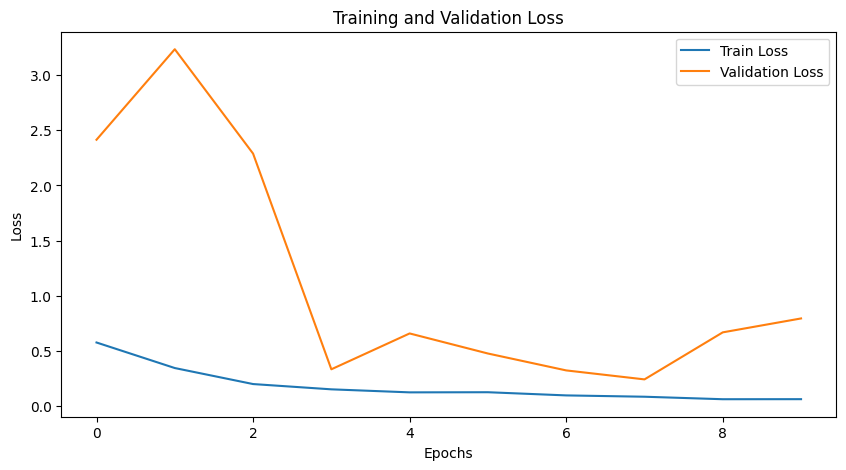

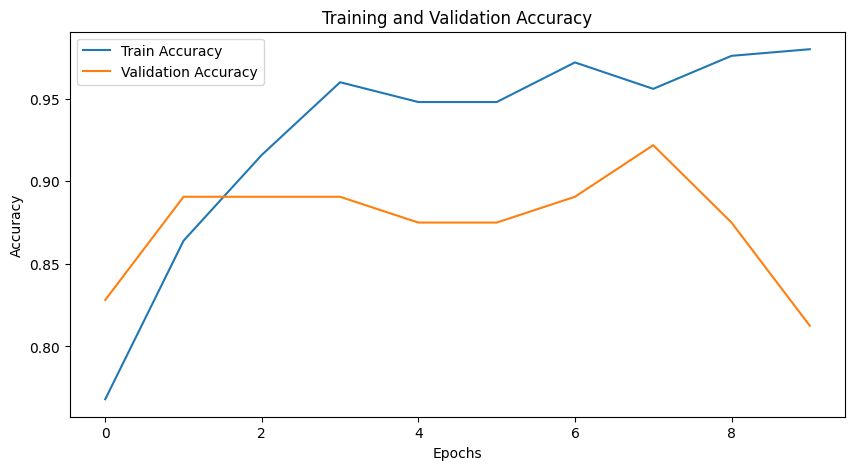

In [7]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()
